In [ ]:
!pip install gymnasium[box2d]
!pip install stable-baselines3
!pip install swig
!pip install gymnasium stable-baselines3 imageio


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 80.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 6.5 MB/s eta 0:00:00


In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
env = gym.make("MountainCar-v0")
eval_env = gym.make("MountainCar-v0")


In [ ]:
model_ppo = PPO(
    policy="MlpPolicy",
    env=env,
    gamma=0.99,   # γ (discount factor, lecture notation)
    verbose=0
)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
def evaluate_policy_MC(model, eval_env, n_episodes=10):
    """
    Monte Carlo estimate of E[G₀ | π]
    """
    mean_reward, std_reward = evaluate_policy(
        model,
        eval_env,
        n_eval_episodes=n_episodes,
        deterministic=True
    )
    return mean_reward, std_reward


In [ ]:
ppo_timesteps = []
ppo_mean_rewards = []
ppo_std_rewards = []

total_steps = 300_000
eval_interval = 25_000
current_steps = 0


In [ ]:
while current_steps < total_steps:
    model_ppo.learn(
        total_timesteps=eval_interval,
        reset_num_timesteps=False
    )

    current_steps += eval_interval

    mean_r, std_r = evaluate_policy_MC(model_ppo, eval_env)

    ppo_timesteps.append(current_steps)
    ppo_mean_rewards.append(mean_r)
    ppo_std_rewards.append(std_r)

    print(f"[PPO] Steps={current_steps}, E[G₀|π]={mean_r:.2f}")


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


[PPO] Steps=25000, E[G₀|π]=-200.00
[PPO] Steps=50000, E[G₀|π]=-200.00
[PPO] Steps=75000, E[G₀|π]=-200.00
[PPO] Steps=100000, E[G₀|π]=-200.00
[PPO] Steps=125000, E[G₀|π]=-200.00
[PPO] Steps=150000, E[G₀|π]=-200.00
[PPO] Steps=175000, E[G₀|π]=-200.00
[PPO] Steps=200000, E[G₀|π]=-200.00
[PPO] Steps=225000, E[G₀|π]=-200.00
[PPO] Steps=250000, E[G₀|π]=-200.00
[PPO] Steps=275000, E[G₀|π]=-200.00
[PPO] Steps=300000, E[G₀|π]=-200.00


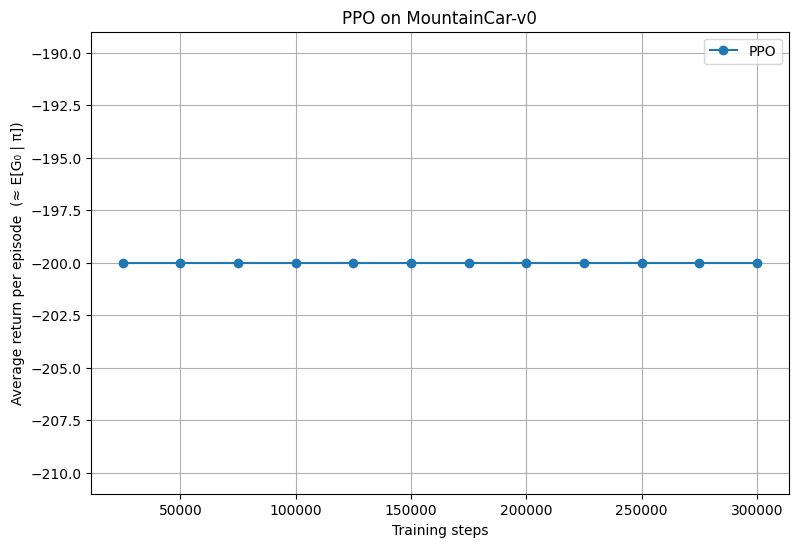

In [ ]:
plt.figure(figsize=(9,6))
plt.plot(ppo_timesteps, ppo_mean_rewards, marker="o", label="PPO")
plt.xlabel("Training steps")
plt.ylabel("Average return per episode  (≈ E[G₀ | π])")
plt.title("PPO on MountainCar-v0")
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt


In [ ]:
env = gym.make("MountainCar-v0")
eval_env = gym.make("MountainCar-v0")

x_min, x_max = env.observation_space.low[0], env.observation_space.high[0]
v_min, v_max = env.observation_space.low[1], env.observation_space.high[1]


In [ ]:
N_x = 18        # number of bins for position
N_v = 14        # number of bins for velocity
N_a = env.action_space.n


In [ ]:
def discretize_state(state):
    x, v = state

    i_x = int((x - x_min) / (x_max - x_min) * N_x)
    i_v = int((v - v_min) / (v_max - v_min) * N_v)

    i_x = np.clip(i_x, 0, N_x - 1)
    i_v = np.clip(i_v, 0, N_v - 1)

    return i_x, i_v


In [ ]:
Q = np.zeros((N_x, N_v, N_a))


In [ ]:
alpha = 0.1      # α — learning rate
gamma = 0.99     # γ — discount factor
epsilon = 1.0    # ε — exploration probability
epsilon_min = 0.05
epsilon_decay = 0.9995


In [ ]:
def epsilon_greedy(Q, state_disc, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randint(N_a)
    else:
        return np.argmax(Q[state_disc])


In [ ]:
total_steps = 1_000_000
eval_interval = 25_000

steps = 0
episode = 0

ql_timesteps = []
ql_mean_rewards = []


In [ ]:
while steps < total_steps:
    obs, _ = env.reset()
    state_disc = discretize_state(obs)
    done = False
    G_episode = 0

    while not done:
        action = epsilon_greedy(Q, state_disc, epsilon)

        next_obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        next_state_disc = discretize_state(next_obs)

        # Q-learning update (LECTURE FORMULA)
        Q[state_disc + (action,)] += alpha * (
            reward
            + gamma * np.max(Q[next_state_disc])
            - Q[state_disc + (action,)]
        )

        state_disc = next_state_disc
        G_episode += reward
        steps += 1

        if steps % eval_interval == 0:
            ql_timesteps.append(steps)
            ql_mean_rewards.append(G_episode)
            print(f"[Q-learning] Steps={steps}, G₀≈{G_episode}")

        if steps >= total_steps:
            break

    # ε decay
    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    episode += 1


[Q-learning] Steps=25000, G₀≈-200.0
[Q-learning] Steps=50000, G₀≈-200.0
[Q-learning] Steps=75000, G₀≈-200.0
[Q-learning] Steps=100000, G₀≈-200.0
[Q-learning] Steps=125000, G₀≈-200.0
[Q-learning] Steps=150000, G₀≈-200.0
[Q-learning] Steps=175000, G₀≈-200.0
[Q-learning] Steps=200000, G₀≈-200.0
[Q-learning] Steps=225000, G₀≈-200.0
[Q-learning] Steps=250000, G₀≈-200.0
[Q-learning] Steps=275000, G₀≈-200.0
[Q-learning] Steps=300000, G₀≈-200.0
[Q-learning] Steps=325000, G₀≈-56.0
[Q-learning] Steps=350000, G₀≈-78.0
[Q-learning] Steps=375000, G₀≈-78.0
[Q-learning] Steps=400000, G₀≈-57.0
[Q-learning] Steps=425000, G₀≈-96.0
[Q-learning] Steps=450000, G₀≈-169.0
[Q-learning] Steps=475000, G₀≈-16.0
[Q-learning] Steps=500000, G₀≈-50.0
[Q-learning] Steps=525000, G₀≈-124.0
[Q-learning] Steps=550000, G₀≈-126.0
[Q-learning] Steps=575000, G₀≈-33.0
[Q-learning] Steps=600000, G₀≈-42.0
[Q-learning] Steps=625000, G₀≈-132.0
[Q-learning] Steps=650000, G₀≈-100.0
[Q-learning] Steps=675000, G₀≈-58.0
[Q-learning] S

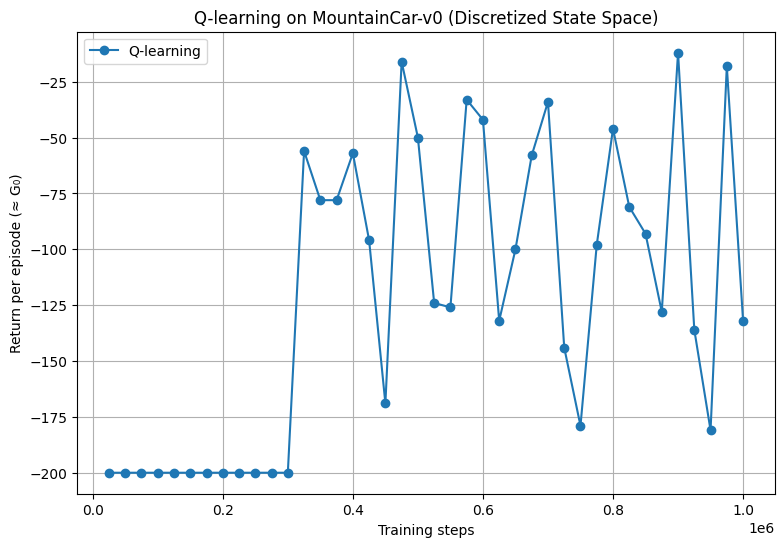

In [ ]:
plt.figure(figsize=(9,6))
plt.plot(ql_timesteps, ql_mean_rewards, marker="o", label="Q-learning")
plt.xlabel("Training steps")
plt.ylabel("Return per episode (≈ G₀)")
plt.title("Q-learning on MountainCar-v0 (Discretized State Space)")
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
def evaluate_q_policy(Q, env, n_episodes=10):
    returns = []

    for _ in range(n_episodes):
        obs, _ = env.reset()
        state_disc = discretize_state(obs)
        done = False
        G = 0

        while not done:
            action = np.argmax(Q[state_disc])  # greedy
            obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            state_disc = discretize_state(obs)
            G += reward

        returns.append(G)

    return np.mean(returns)


In [ ]:
if steps % eval_interval == 0:
    mean_G = evaluate_q_policy(Q, eval_env)
    ql_timesteps.append(steps)
    ql_mean_rewards.append(mean_G)
    print(f"[Q-learning] Steps={steps}, E[G₀|π]={mean_G}")


[Q-learning] Steps=1000000, E[G₀|π]=-186.2


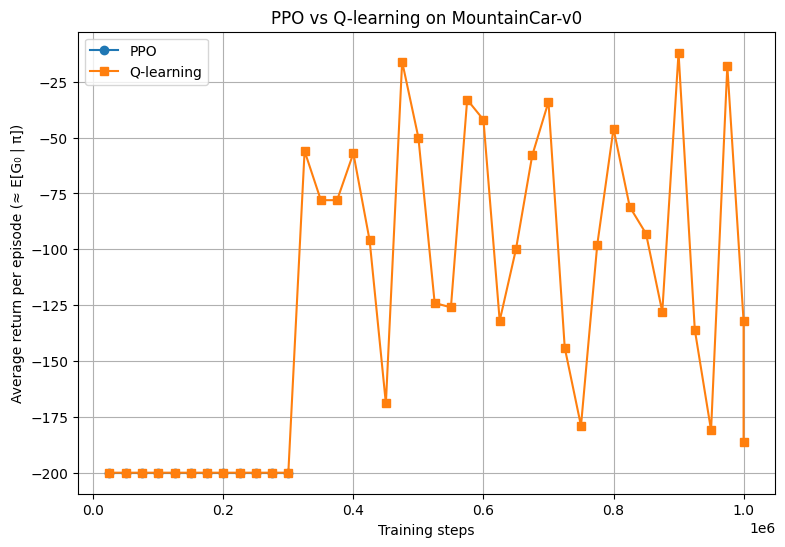

In [ ]:
plt.figure(figsize=(9,6))
plt.plot(ppo_timesteps, ppo_mean_rewards, marker="o", label="PPO")
plt.plot(ql_timesteps, ql_mean_rewards, marker="s", label="Q-learning")
plt.xlabel("Training steps")
plt.ylabel("Average return per episode (≈ E[G₀ | π])")
plt.title("PPO vs Q-learning on MountainCar-v0")
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
### PPO vs Q-learning – Comparison (Lecture-based)

Both algorithms are evaluated on MountainCar-v0, a task with sparse
and delayed rewards requiring energy accumulation.

PPO, despite using neural networks and policy optimization, fails to
significantly improve within 300,000 steps. This behavior is consistent
with the theory presented in the lectures: on-policy methods suffer
from high variance and poor sample efficiency in sparse-reward
environments without shaping.

Q-learning, implemented using a discretized state space, eventually
shows partial improvement after several hundred thousand steps. However,
learning is unstable and highly sensitive to discretization and
exploration, illustrating the limitations of tabular methods in
continuous domains.

Overall, PPO is more flexible but not necessarily more effective in this
setting, while Q-learning closely follows the theoretical expectations
but requires significantly more data and careful approximation.
